In [2]:
%pip install matplotlib numpy pandas scikit-learn 

Note: you may need to restart the kernel to use updated packages.


## Treinando modelos

Aqui vamos entrar em detalhes de implementação de modelos lineares em grande maioria...

### Regressão Linear

O modelo mais simples possivel para a tarefa de regressão... nele cada predição é dada por uma soma das features ponderada por pesos aprendidos e (se quiser) somado um termo bias. Teriamos que a predição *y_hat = w0.1 + w1.x1 + wn.xn* em que podemos considerar por convenção que a primeira posição do vetor de features vai ser sempre 1 (sendo multiplicado pelo bias). Nessa formulação temos que o a predição *y_hat* é simplesmente o produto interno/escalar do vetor de features *x* e vetor de pesos *w* e *n* é o numero de features. Mas como treinar esse modelo ? 

Primeiramente precisamos medir o quão bem o modelo esta performando e para isso podemos usar o RMSE que é uma versão interpretável da MSE... MSE é o erro médio quadratico, ou seja, calculamos o erro para cada instancia e tiramos a media (no RMSE nos tirariamos a raiz dessa media para voltar a escala original). Otimizar MSE é mais facil que RMSE e elas levam exatamente para o mesmo lugar durante a otimização e portanto a MSE é preferida como métrica de perda.

Agora como encontrar os pesos W tal que minimizem o valor do MSE que é nossa função de qualidade ? Existem algumas maneiras paramétricas de se fazer isso (formula fechada) e não paramétricas através de otimização... 


Paramétricas: 

- Equação Normal: Essa equação é fruto da derivada da MSE igualada a 0 e desenvolvida em função de W (theta). Se tornando a função:

$$
\theta = (X^T X)^{-1} X^T y
$$

Nessa equação precisamos calcular a inversa e se existir colunas com multicolinearidade (fortemente correlacionadas) a matriz chega perto de ser singular (matriz é singular quando suas colunas são linearmente dependentes e consequentemente não é inversivel) e gera numeros instaveis gerando erros numéricos. Além disso, se temos mais features que linhas a matriz será singular e a Normal falha novamente. 

- SVD (LinearRegression do sklearn): Os problemas anteriores são resolvidos através do calculo de uma pseudoinversa usando decomposição SVD:

    - Primeiro decompomos a matriz de features usando SVD em que U (mxm) em que cada coluna é um autovetor no espaço das linhas (amostras)... esse espaço é gerado por XX^t (simétrica) em que cada posição ij dessa matriz representa a proximidade entre a amostra i com amostra j... da mesma maneira V (nxn) é calculado mas no espaço das features X^tX (simétrica) e representa a associação linear entre as features... a matriz do meio são os autovalores V na diagonal principal... os autovetores mostram as direções onde os dados estão mais "espalhados". O autovetor com o maior autovalor é a direção da informação mais importante do seu dataset.:

    $$
    X = U \Sigma V^T
    $$ 

    - Calculamos a pseudoinversa usando a matriz diagonal com os valores não nulos invertidos:

    $$
    X^+ = V \Sigma^+ U^T
    $$

    - Usamos a pseudoinversa para calcular os parametros.

    $$
    \hat{\theta} = X^+ y = V \Sigma^+ U^T y
    $$

Complexidade dos algoritmos: Na equação normal é necessário calcular a inversa da matriz X com n features e isso tem complexidade de O(n³) enquanto o SVD tem complexidade de O(m*n²). Ou seja, esses algoritmos não escalam tão bem quando o numero de features é muito grande (100000 por exemplo) e podem se tornar lentos. Entretanto, as equações escalam muito bem em relação ao tamanho do dataset (linhas) sendo ambos linear em relação a m linhas. Isso é muito util mas e em caso em que o dataset não cabe em memória ? e em casos que temos muitas colunas ?



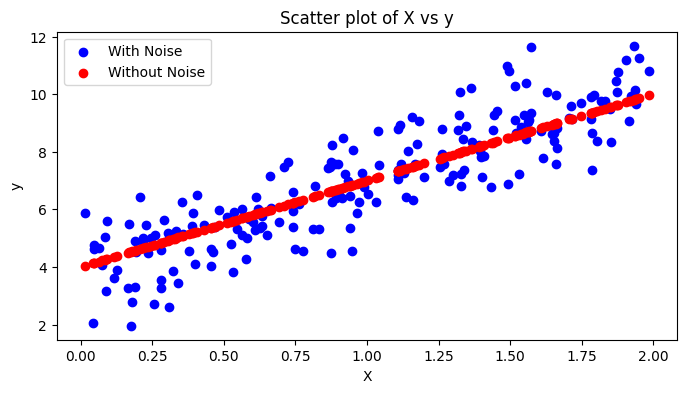

Theta best (com ruído): [[3.69084138]
 [3.32960458]]
Theta best (sem ruído): [[4.]
 [3.]]
Theta best (com ruído, regressão linear do sklearn): [np.float64(3.6908413834642553), np.float64(3.3296045821528386)]
Theta best (com ruído, lstsq): [[3.69084138]
 [3.32960458]]


In [3]:
import numpy as np
rng = np.random.default_rng(seed=42)
m = 200 
X = 2 * rng.random((m, 1)) # 200 rows, 1 column
y_noise = 4 + 3 * X + rng.standard_normal((m, 1)) # y = 4 + 3X + noise

# quanto mais ruido maior a variancia dos dados, mais dificil de encontrar a linha de regressão
# conseguimos encontrar a linha de regressão, mas ela não será tão precisa quanto a linha sem ruído
# quanto menor o dataset, mais difícil de encontrar a linha de regressão, pois o modelo tem menos dados para aprender

y_not_noise = 4 + 3 * X # y = 4 + 3X without noise

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.scatter(X, y_noise, color='blue', label='With Noise')
plt.scatter(X, y_not_noise, color='red', label='Without Noise')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Scatter plot of X vs y")
plt.legend()
plt.show()

# Equação Normal:

X_b = np.c_[np.ones((m, 1)), X] # Adiciona x0 = 1 para cada instância
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_noise) # Calcula os melhores parâmetros usando a equação normal
print("Theta best (com ruído):", theta_best)

theta_best_no_noise = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_not_noise) # Calcula os melhores parâmetros sem ruído
print("Theta best (sem ruído):", theta_best_no_noise)

from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y_noise) # Treina o modelo com os dados com ruído
print("Theta best (com ruído, regressão linear do sklearn):", [lin_reg.intercept_[0], lin_reg.coef_[0][0]])

theta_lstsq = np.linalg.lstsq(X_b, y_noise, rcond=None)[0] # Calcula os melhores parâmetros usando a função lstsq do NumPy
print("Theta best (com ruído, lstsq):", theta_lstsq)

#### Gradiente Descendente

Gradiente Desc. é um algoritmo de otimização que trabalha se movimentando no espaço n-dimensional gerado pelos parâmetros do modelo, ou seja, os pesos *w* de tamanho *n*. O algoritmo começa em um ponto aleatório normalmente com random inicialization e apartir de lá começa a dar passos de tamanho *alpha* (learning rate) na direção oposta do vetor gradiente. O vetor gradiente é um vetor no espaço dos parametros, ou seja, se o modelo tem 2 parametros então o vetor gradiente esta em R² e é algo como [0,1]... esse vetor é composto pelas derivadas parciais da Loss (MSE por exemplo) em relação aos parametros, então se temos um vetor de parametros *w* = [w0,w1], o vetor gradiente do espaço dos parametros serão as derivadas parciais *[dJ/dw0, dJ/dw1]* (essas coordenadas são calculadas com base no ponto do espaço de parametros que estamos agora, ou seja, usamos os parametros atuais para calcular essas derivadas). Cada uma dessas derivadas diz algo como: nesse ponto se mantermos todos os outros parametros fixos e aumentarmos w0 teremos um aumento da loss de dJ/dw0. O vetor gradiente é composto por essas derivadas e aponta para a direção de maior crescimento da função de Loss... uma vez que queremos minimizar a função de Loss nos usamos o negativo do vetor gradiente. A equação usada para atualização dos parametros atuais (se mover no espaço) é: 

$$
\theta_{j} := \theta_{j} - \alpha \frac{\partial}{\partial \theta_{j}} J(\theta_0, \theta_1, ..., \theta_n)
$$
Forma vetorial:
$$
\theta := \theta - \alpha \nabla_{\theta} J(\theta)
$$

Repare que o quanto os parametros são alterados em cada epoca depende de 2 coisas: O gradiente parcial do parâmetro j que representa que se aumentarmos o parametro a loss ira descer ou subir uma quantidade, ou seja, se estamos em uma descida ou subida e o quao ingrime ela é... O outro fator é *alpha* que controla o tamanho do passo que vamos dar na direção contrária do vetor gradiente, ou melhor, na direção contrária do crescimento da loss naquele parametros. Se *alpha* é muito baixo nossa convergencia (chegar no minimo) vai acontecer mais lentamente uma vez que estamos dando passos curtos, em contrapartida se ele for muito alto pode ser que o modelo nem mesmo chegue a convergir pois pode acontecer de dele começar a encontrar pontos muito ingrimes que façam a alteração do parametro ser tão brusca que pula os vales e começa a super indefinidamente... Além disso, nem mesmo com *alphas* bons a convergencia é garantida já que existem minimos locais e globais em funções não convexas (MSE é uma função convexa e que o conceito é que para qualquer 2 pontos que escolhermos a função estara em baixo da linha que conecta esses dois pontos (não convexa pode ser convexa em um intervalo)). Um minimo é global quando não existe nenhum ponto na função menor que ele... e o gradiente descendente não garante minimo global para funções não convexas. Se uma função tiver platos (regiões "planas") o algoritmo também fica estagnado uma vez que o gradiente será 0. Uma forma interessante de ver a importancia de escalar as variaveis com padronização ou normalização é observar o formato do espaço gerado por variaveis não escaladas e escalas... o espaço escalado tem formato mais comportado que permite o algoritmo encontrar o minimo em menos passos...

![image.png](imagens/scaledvsnot.png)


Grandiente descendente em batch (lote):

Nessa versão do algoritmo nos usamos todos os dados do dataset em cada epoca (iteração) do treinamento, ou seja, se temos 10 iterações nós iremos atualizar os parametros do modelo 10 vezes e em todas vamos usar todo o dataset... essa versão pode ser interessante e mais rapida em convergir para datasets pequenos e medios com muitas features (ponto fraco das soluções paramétricas) mas em datasets com poucas features e muitas linhas ele será extremamente lento. Para encontrar bons parametros de learning rate podemos usar GridSearch ou RandomSearch e explorar varias possibilidades... porém alguns valores de learning rate irão fazer com que o algoritmo demore muito para convergir e isso tomará muito tempo e portanto é interessante limitar o numero de epocas... encontrar um bom numero de epocas pode ser desafiador também já que não sabemos de antemão quando é a hora certa de parar pois se for muito poucas podemos perder tempo e estar longe do minimo mas se for muito grande podemos já estar no minimo e gastar processamento atoa... uma solução para isso é o *early stopping* que usa um parametro *e* chamado tolerancia que é um valor bem pequeno e a cada epoca comparamos o valor da loss antiga com o valor da loss nova e se a diferença entre elas for menor que *e*, paramos o algoritmo pois não tem mais atualização significante. Também é normal usar early stopping com loss da validação que para imediatamente quando a loss da validação para de cair... também é comum manter um máximo de epocas para evitar rodar infinitamente.

Apenas por ilustração essa é a derivada da loss MSE (em forma não vetorial e vetorial) que usamos para calcular os gradientes:

$$
\frac{\partial MSE}{\partial z_i} = -\frac{2}{n} (y_i - z_i)
$$

$$
\nabla_{\mathbf{w}} MSE = -\frac{2}{n} X^T (\mathbf{y} - X\mathbf{w})
$$

In [20]:
# batch gradient descent

n_epochs = 1000
theta = np.random.randn(2, 1) # inicializa os parâmetros aleatoriamente
learning_rate = 0.1

for epoch in range(n_epochs):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y_noise) # calcula os gradientes
    theta = theta - learning_rate * gradients # atualiza os parâmetros

print("Theta best (com ruído, batch gradient descent):", theta) # exatamente o mesmo resultado das equações



Theta best (com ruído, batch gradient descent): [[3.69084138]
 [3.32960458]]
